In [2]:
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler

from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.naive_bayes import BernoulliNB
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import(confusion_matrix,precision_score,recall_score,f1_score,roc_curve,auc,classification_report)

In [3]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
columns = ["age", "sex", "cp", "trestbps", "chol", "fbs", "restecg", 
           "thalach", "exang", "oldpeak", "slope", "ca", "thal", "target"]
df = pd.read_csv(url, names=columns, na_values="?")

# Binary classification
df["target"] = (df["target"] > 0).astype(int)

### Data Cleaning

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


In [6]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.458746
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,0.499120
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,1.000000


In [7]:
#check missing values
print("Missing values per column:\n",df.isnull().sum())

Missing values per column:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64


In [8]:
#handle missing values:imputation
num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

In [9]:
cont_cols = ['trestbps', 'chol', 'thalach', 'oldpeak']
df[cont_cols] = num_imputer.fit_transform(df[cont_cols])

cat_cols = ['ca', 'thal', 'slope', 'fbs', 'restecg', 'exang']
df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

print("Missing values per column:\n",df.isnull().sum())

Missing values per column:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [10]:
#address noisy or inconsistent values

has_zero = df.isin([0]).any()
has_zero

age         False
sex          True
cp          False
trestbps    False
chol        False
fbs          True
restecg      True
thalach     False
exang        True
oldpeak      True
slope       False
ca           True
thal        False
target       True
dtype: bool

In [11]:
#use the Interquartile Range (IQR) method to handle extreme noise
for col in ['trestbps', 'chol']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    # Clip values to the bounds to remove extreme noise
    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)

### Feature Engineering

In [13]:
#transformations

#Normalization
scaler = MinMaxScaler()
num_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
df[num_cols] = scaler.fit_transform(df[num_cols])

#Standardization
scaler = StandardScaler()
num_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
df[num_cols] = scaler.fit_transform(df[num_cols])

In [14]:
#one-hot encoding
cat_to_encode = ['cp', 'restecg', 'slope', 'thal']
df = pd.get_dummies(df, columns=cat_to_encode, drop_first=True)

### Training Setup

In [16]:
X=df.drop('target',axis=1)
Y=df['target']
X_train,X_test,y_train,y_test=train_test_split(X,Y,test_size=0.25,random_state=42)

### Naive Bayes - BernoulliNB

In [17]:
results = []

#Naive Bayes:BernoulliNB
for alpha in [1.0, 0.01]:
    pipeline = make_pipeline(
        SimpleImputer(strategy='most_frequent'), 
        BernoulliNB(alpha=alpha)
    )
    
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    results.append({
        "Model": f"Naive Bayes (alpha={alpha})",
        "Accuracy": accuracy_score(y_test, y_pred)
    })

In [19]:
#evaluation

# Naive Bayes: BernoulliNB
for alpha in [1.0, 0.01]:
    pipeline = make_pipeline(
        SimpleImputer(strategy='most_frequent'),
        BernoulliNB(alpha=alpha)
    )
    
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    print(f"\nNaive Bayes (alpha={alpha})")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-score:  {f1:.4f}")


Naive Bayes (alpha=1.0)
Accuracy:  0.8421
Precision: 0.8378
Recall:    0.8378
F1-score:  0.8378

Naive Bayes (alpha=0.01)
Accuracy:  0.8421
Precision: 0.8378
Recall:    0.8378
F1-score:  0.8378


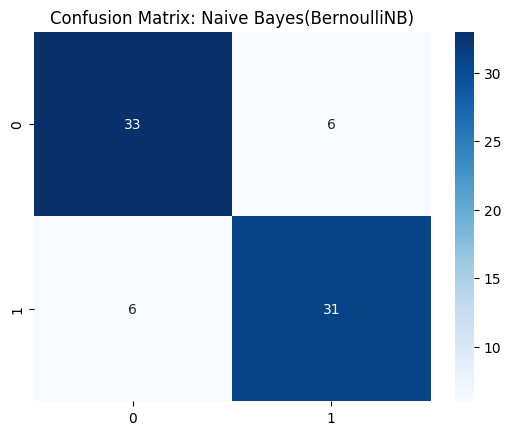

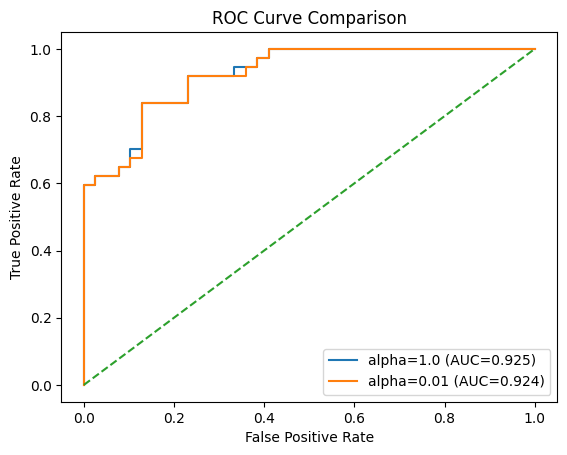

In [20]:
#visualization

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix: Naive Bayes(BernoulliNB)")
plt.show()

# ROC Curve
plt.figure()

for alpha in [1.0, 0.01]:

    pipeline = make_pipeline(
        SimpleImputer(strategy='most_frequent'),
        BernoulliNB(alpha=alpha)
    )

    pipeline.fit(X_train, y_train)
    y_prob = pipeline.predict_proba(X_test)[:,1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"alpha={alpha} (AUC={roc_auc:.3f})")

plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

### Linear Regression

In [22]:
#Linear Regression
pipeline = make_pipeline(
    SimpleImputer(strategy='mean'),
    LinearRegression()
)
    
pipeline.fit(X_train, y_train)
raw_preds = pipeline.predict(X_test)
    
y_pred = (raw_preds >= 0.5).astype(int)
    
results.append({
    "Model": f"Linear Regression",
    "Accuracy": accuracy_score(y_test, y_pred)
    })

In [24]:
#evaluation
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"\nLinear Regression")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")


Linear Regression
Accuracy:  0.8421
Precision: 0.8378
Recall:    0.8378
F1-score:  0.8378


In [ ]:
#visualization

#confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix: Linear Regression")
plt.show()

#ROC curve
fpr, tpr, _ = roc_curve(y_test, raw_preds)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f"Linear Regression (AUC={roc_auc:.3f})")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

### Ridge Regression

In [26]:
#Ridge Regression
for alpha in [1.0, 0.01]:
    pipeline = make_pipeline(
        SimpleImputer(strategy='mean'), 
        Ridge(alpha=alpha)
    )
    
    pipeline.fit(X_train, y_train)
    raw_preds = pipeline.predict(X_test)
    y_pred = (raw_preds >= 0.5).astype(int)
    
    results.append({
        "Model": f"Ridge Regression(L2)(alpha={alpha})",
        "Accuracy": accuracy_score(y_test, y_pred)
    })

In [27]:
#evaluation
for alpha in [1.0, 0.01]:
    pipeline = make_pipeline(
        SimpleImputer(strategy='mean'), 
        Ridge(alpha=alpha)
    )
    
    pipeline.fit(X_train, y_train)
    raw_preds = pipeline.predict(X_test)
    y_pred = (raw_preds >= 0.5).astype(int)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    print(f"\nRidge Regression (alpha={alpha})")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-score:  {f1:.4f}")


Ridge Regression (alpha=1.0)
Accuracy:  0.8553
Precision: 0.8421
Recall:    0.8649
F1-score:  0.8533

Ridge Regression (alpha=0.01)
Accuracy:  0.8421
Precision: 0.8378
Recall:    0.8378
F1-score:  0.8378


In [ ]:
#visualization

#confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix: Ridge Regression")
plt.show()

#ROC curve
fpr, tpr, _ = roc_curve(y_test, raw_preds)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f"Ridge Regression (AUC={roc_auc:.3f})")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

### LASSO Regression

In [29]:
#LASSO Regression
for alpha in [1.0, 0.01]:
    pipeline = make_pipeline(
        SimpleImputer(strategy='mean'), 
        Lasso(alpha=alpha)
    )
    
    pipeline.fit(X_train, y_train)
    raw_preds = pipeline.predict(X_test)
    y_pred = (raw_preds >= 0.5).astype(int)
    
    results.append({
        "Model": f"LASSO Regression(L1)(alpha={alpha})",
        "Accuracy": accuracy_score(y_test, y_pred)
    })

In [30]:
#evaluation
for alpha in [1.0, 0.01]:
    pipeline = make_pipeline(
        SimpleImputer(strategy='mean'), 
        Lasso(alpha=alpha)
    )
    
    pipeline.fit(X_train, y_train)
    raw_preds = pipeline.predict(X_test)
    y_pred = (raw_preds >= 0.5).astype(int)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    print(f"\nLASSO Regression (alpha={alpha})")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-score:  {f1:.4f}")


LASSO Regression (alpha=1.0)
Accuracy:  0.5132
Precision: 0.0000
Recall:    0.0000
F1-score:  0.0000

LASSO Regression (alpha=0.01)
Accuracy:  0.8816
Precision: 0.8889
Recall:    0.8649
F1-score:  0.8767


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


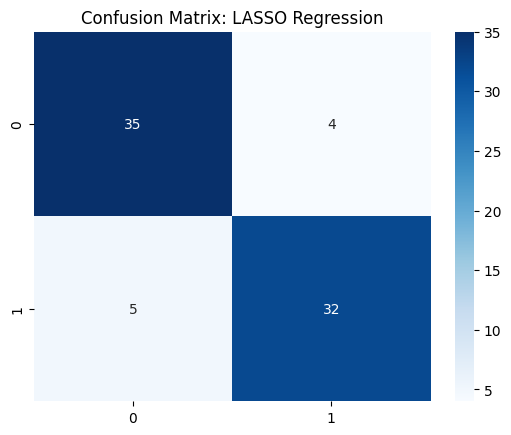

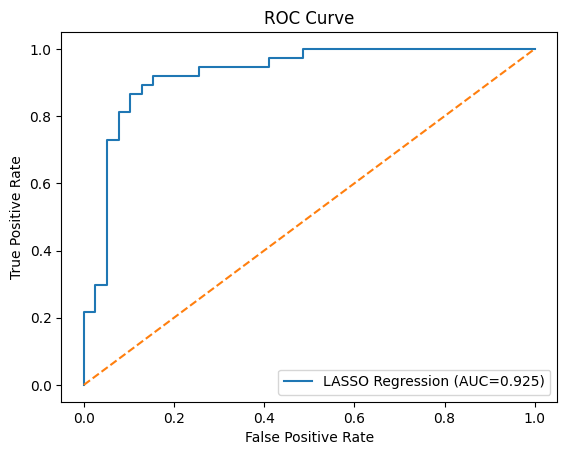

In [31]:
#visualization

#confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix: LASSO Regression")
plt.show()

#ROC curve
fpr, tpr, _ = roc_curve(y_test, raw_preds)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f"LASSO Regression (AUC={roc_auc:.3f})")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

### Comparasion

In [32]:
results

[{'Model': 'Naive Bayes (alpha=1.0)', 'Accuracy': 0.8421052631578947},
 {'Model': 'Naive Bayes (alpha=0.01)', 'Accuracy': 0.8421052631578947},
 {'Model': 'Linear Regression', 'Accuracy': 0.8421052631578947},
 {'Model': 'Ridge Regression(L2)(alpha=1.0)', 'Accuracy': 0.8552631578947368},
 {'Model': 'Ridge Regression(L2)(alpha=0.01)', 'Accuracy': 0.8421052631578947},
 {'Model': 'LASSO Regression(L1)(alpha=1.0)', 'Accuracy': 0.5131578947368421},
 {'Model': 'LASSO Regression(L1)(alpha=0.01)', 'Accuracy': 0.881578947368421}]